In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

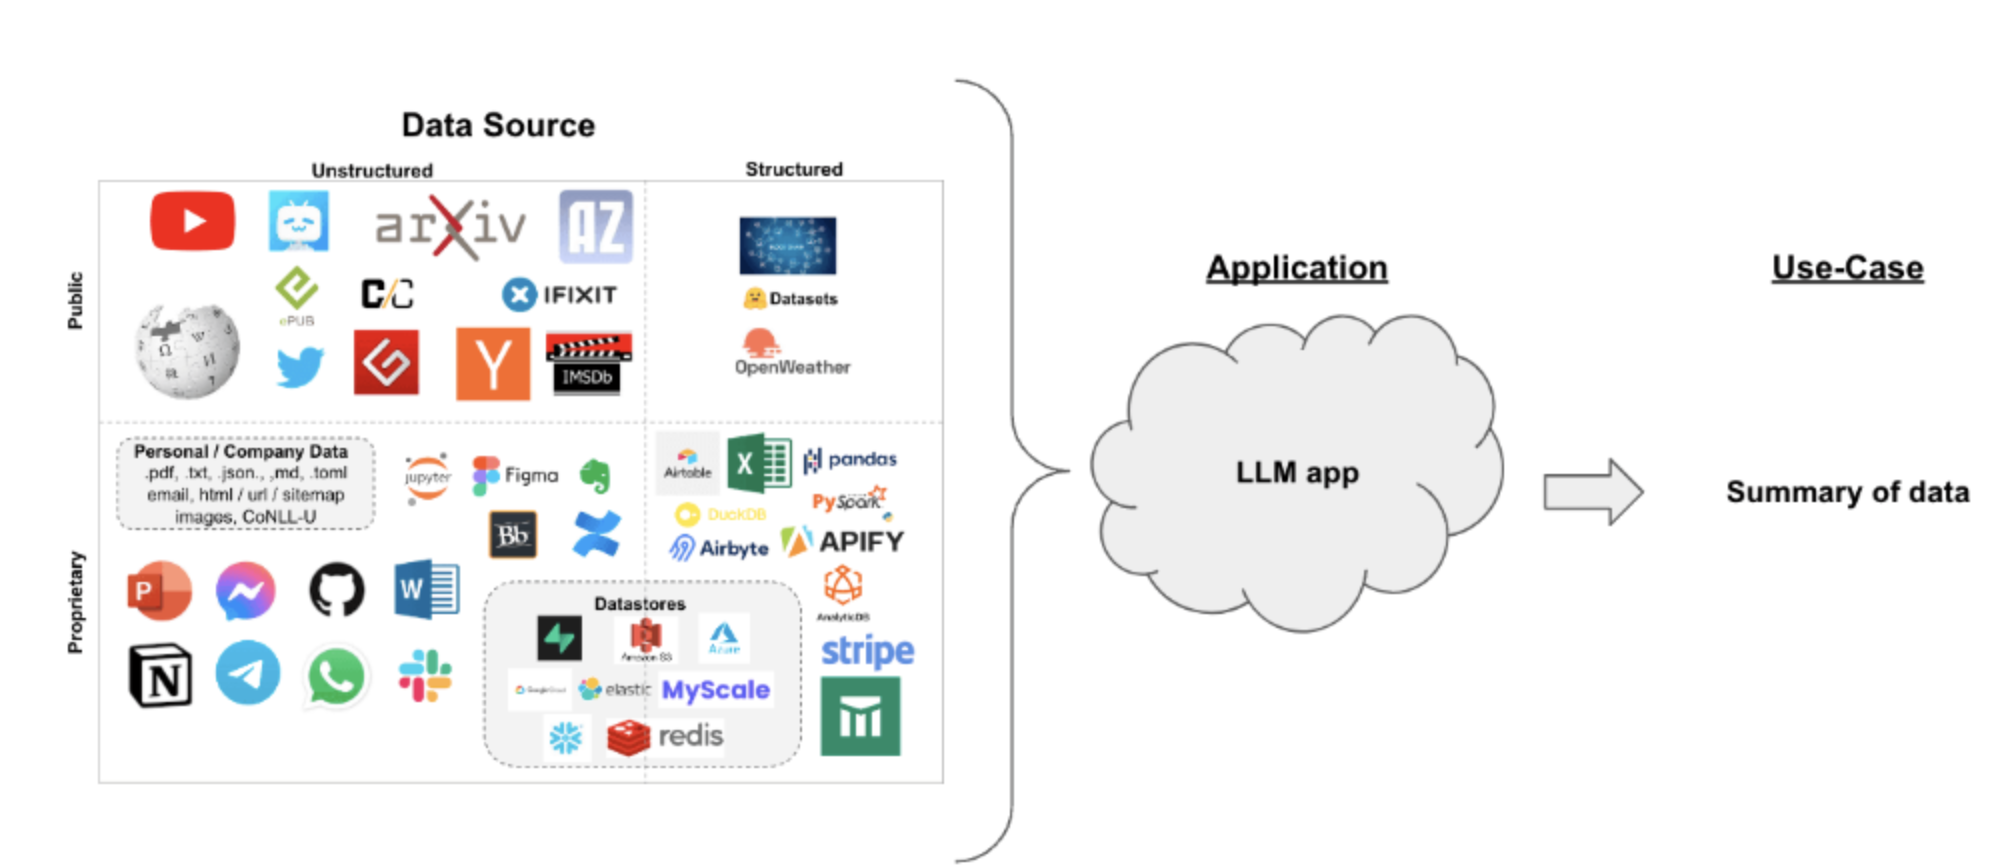

In [3]:
from langchain_groq import ChatGroq
api_key=os.getenv("GROQ_API_KEY")
llm=ChatGroq(groq_api_key=api_key,model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1125afa10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1128d0590>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from langchain_classic.schema import(
    AIMessage,
    HumanMessage,SystemMessage
)

In [6]:
speech="""
People across the country, involved in government, political, and social activities, are dedicating their time to make the ‘Viksit Bharat Sankalp Yatra’ (Developed India Resolution Journey) successful. Therefore, as a Member of Parliament, it was my responsibility to also contribute my time to this program. So, today, I have come here just as a Member of Parliament and your ‘sevak’, ready to participate in this program, much like you.

In our country, governments have come and gone, numerous schemes have been formulated, discussions have taken place, and big promises have been made. However, my experience and observations led me to believe that the most critical aspect that requires attention is ensuring that the government’s plans reach the intended beneficiaries without any hassles. If there is a ‘Pradhan Mantri Awas Yojana’ (Prime Minister’s housing scheme), then those who are living in jhuggis and slums should get their houses. And he should not need to make rounds of the government offices for this purpose. The government should reach him. Since you have assigned this responsibility to me, about four crore families have got their ‘pucca’ houses. However, I have encountered cases where someone is left out of the government benefits. Therefore, I have decided to tour the country again, to listen to people’s experiences with government schemes, to understand whether they received the intended benefits, and to ensure that the programs are reaching everyone as planned without paying any bribes. We will get the real picture if we visit them again. Therefore, this ‘Viksit Bharat Sankalp Yatra’ is, in a way, my own examination. I want to hear from you and the people across the country whether what I envisioned and the work I have been doing aligns with reality and whether it has reached those for whom it was meant.

It is crucial to check whether the work that was supposed to happen has indeed taken place. I recently met some individuals who utilized the Ayushman card to get treatment for serious illnesses. One person met with a severe accident, and after using the card, he could afford the necessary operation, and now he is recovering well. When I asked him, he said: “How could I afford this treatment? Now that there is the Ayushman card, I mustered courage and underwent an operation. Now I am perfectly fine.”  Such stories are blessings to me.

The bureaucrats, who prepare good schemes, expedite the paperwork and even allocate funds, also feel satisfied that 50 or 100 people who were supposed to get the funds have got it. The funds meant for a thousand villages have been released. But their job satisfaction peaks when they hear that their work has directly impacted someone’s life positively. When they see the tangible results of their efforts, their enthusiasm multiplies. They feel satisfied. Therefore, ‘Viksit Bharat Sankalp Yatra’ has had a positive impact on government officers. It has made them more enthusiastic about their work, especially when they witness the tangible benefits reaching the people. Officers now feel satisfied with their work, saying, “I made a good plan, I created a file, and the intended beneficiaries received the benefits.” When they find that the money has reached a poor widow under the Jeevan Jyoti scheme and it was a great help to her during her crisis, they realise that they have done a good job. When a government officer listens to such stories, he feels very satisfied.

There are very few who understand the power and impact of the ‘Viksit Bharat Sankalp Yatra’. When I hear people connected to bureaucratic circles talking about it, expressing their satisfaction, it resonates with me. I’ve heard stories where someone suddenly received 2 lakh rupees after the death of her husband, and a sister mentioned how the arrival of gas in her home transformed her lives. The most significant aspect is when someone says that the line between rich and poor has vanished. While the slogan ‘Garibi Hatao’ (Remove Poverty) is one thing, but the real change happens when a person says, “As soon as the gas stove came to my house, the distinction between poverty and affluence disappeared.
"""

In [7]:
chat_message=[
    SystemMessage(content="You are expert with experise in summarizing speeched"),
    HumanMessage(content=f"Please provide a short and concisse summary of the follow speech:\n Text:{speech}")
]

In [8]:
llm.get_num_tokens(speech)

/Users/venu/Documents/AI/LangChain/venv/lib/python3.14/site-packages/langchain_core/language_models/base.py:463: UserWarning: Using fallback GPT-2 tokenizer for token counting. Token counts may be inaccurate for non-GPT-2 models. For accurate counts, use a model-specific method if available.
  return len(self.get_token_ids(text))
/Users/venu/Documents/AI/LangChain/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


909

In [13]:
#getting the summary
llm.invoke(chat_message).content

'The MP explains that he joined the “Viksit Bharat Sankalp Yatra” to personally verify that government schemes—such as housing, health, and welfare programmes—actually reach the intended beneficiaries. He shares anecdotes of people who benefited from Ayushman cards, housing, and cash transfers, and notes how these successes boost the morale of bureaucrats who see tangible results. The journey is portrayed as a self‑audit, encouraging both citizens and officials to confirm that promises translate into real, poverty‑reducing outcomes.'

# PromptTemplate Text Summarization

In [14]:

from langchain_classic.chains import LLMChain
from langchain_core.prompts import PromptTemplate


# 2. Define the PromptTemplate with 'speech' as the input variable
speech_template = """
You are an expert speech analyst. Summarize the following speech clearly and concisely.
Extract the speaker's core message, tone, and call to action.

Speech:
{speech}

Translate the precise summary to {language}
"""

prompt = PromptTemplate(
    input_variables=["speech","language"],
    template=speech_template
)

# 3. Create the LLMChain
summarize_chain = LLMChain(llm=llm, prompt=prompt)



response = summarize_chain.run({'speech':speech,'language':"Telugu"})
print(response)


/var/folders/h_/3_y8qn2x5t5_7mw2r32c4dp40000gn/T/ipykernel_3844/105325130.py:22: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  summarize_chain = LLMChain(llm=llm, prompt=prompt)
/var/folders/h_/3_y8qn2x5t5_7mw2r32c4dp40000gn/T/ipykernel_3844/105325130.py:26: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  response = summarize_chain.run({'speech':speech,'language':"Telugu"})


**Core Message**  
The speaker urges that government schemes must reach every intended beneficiary without hassle, and calls for a nationwide “Viksit Bharat Sankalp Yatra” to listen to people’s real experiences, verify that benefits are delivered, and hold officials accountable.

**Tone**  
Committed, encouraging, and hopeful—presenting the journey as a personal and collective audit that inspires both citizens and bureaucrats.

**Call to Action**  
Continue the “Sankalp Yatra,” engage directly with beneficiaries, verify and improve delivery of schemes, and encourage officials to see tangible results so they feel motivated to keep the cycle of service alive.

---

**తెలుగులో సారాంశం**  

**ప్రధాన సందేశం**  
సర్కారు పథకాలు ప్రతి లబ్ధిదారుని చేరుకోవాలి, అడ్డంకులు లేకుండా; ఇందుకోసం “వికసిత భారత్ సంకల్ప యాత్ర” ద్వారా ప్రజల నిజమైన అనుభవాలు విని, ప్రయోజనాలు చేరుతున్నాయో లేదో తనిఖీ చేసి, అధికారులను బాధ్యతాయుతంగా నిలబెట్టాలి.

**శైలి**  
నిబద్ధతతో, ప్రేరణాత్మకంగా, ఆశావహంగా—యాత్రను వ్యక్తిగత, సా

## StuffDocumentChain Text summarization

In [16]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("apjspeech.pdf")
docs = loader.load_and_split()
docs

/var/folders/h_/3_y8qn2x5t5_7mw2r32c4dp40000gn/T/ipykernel_3844/419441476.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


[Document(metadata={'producer': 'GPL Ghostscript 8.15', 'creator': 'PScript5.dll Version 5.2', 'creationdate': 'D:20070730160943', 'moddate': 'D:20070730160943', 'title': 'Microsoft Word - Document1', 'author': 'Shri', 'source': 'apjspeech.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='A P J Abdul Kalam Departing speech \n \n \nFriends, I am delighted to address you all, in the country and those livi ng abroad, after \nworking with you and completing five beautiful and eventful years in Rashtrapati \nBhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I \nenjoyed every minute of my tenure enriched by the wonderful assoc iation from each one \nof you, hailing from different walks of life, be it politics, sci ence and technology, \nacademics, arts, literature, business, judiciary, administration, local bodies, farming, \nhome makers, special children, media and above all from the youth and st udent \ncommunity who are the future wealt

In [17]:
template=""" Write a concise and short summary of the following speech,
Speech :{text}

 """
prompt=PromptTemplate(input_variables=['text'],
                      template=template)

In [21]:
from langchain_classic.chains import load_summarize_chain

chain = load_summarize_chain(llm, chain_type="stuff", prompt=prompt,verbose=True)
summary = chain.run(docs)
print(summary)



> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
 Write a concise and short summary of the following speech,
Speech :A P J Abdul Kalam Departing speech 
 
 
Friends, I am delighted to address you all, in the country and those livi ng abroad, after 
working with you and completing five beautiful and eventful years in Rashtrapati 
Bhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I 
enjoyed every minute of my tenure enriched by the wonderful assoc iation from each one 
of you, hailing from different walks of life, be it politics, sci ence and technology, 
academics, arts, literature, business, judiciary, administration, local bodies, farming, 
home makers, special children, media and above all from the youth and st udent 
community who are the future wealth of our country. During my intera ction at 
Rashtrapati Bhavan in Delhi and at every state and union territor y as well as through my 
online in

## Map-reduce to Summarize Large documents

In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

final_documents = RecursiveCharacterTextSplitter(chunk_size=2000,chunk_overlap=100).split_documents(docs)
final_documents

[Document(metadata={'producer': 'GPL Ghostscript 8.15', 'creator': 'PScript5.dll Version 5.2', 'creationdate': 'D:20070730160943', 'moddate': 'D:20070730160943', 'title': 'Microsoft Word - Document1', 'author': 'Shri', 'source': 'apjspeech.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='A P J Abdul Kalam Departing speech \n \n \nFriends, I am delighted to address you all, in the country and those livi ng abroad, after \nworking with you and completing five beautiful and eventful years in Rashtrapati \nBhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I \nenjoyed every minute of my tenure enriched by the wonderful assoc iation from each one \nof you, hailing from different walks of life, be it politics, sci ence and technology, \nacademics, arts, literature, business, judiciary, administration, local bodies, farming, \nhome makers, special children, media and above all from the youth and st udent \ncommunity who are the future wealt

In [23]:
len(final_documents)

13

In [24]:
chunks_prompt = """
Please summarize the below speech:
Speech: {text}
Summary:
"""
map_prompt_template=PromptTemplate(input_variables=['text'],
                                    template=chunks_prompt)

In [25]:
final_prompt='''
Provide the final summary of the entire speech with these important points.
Add a Motivation Title,Start the precise summary with an introduction and provide the summary in number 
points for the speech.
Speech:{text}

'''

final_prompt_template=PromptTemplate(input_variables=['text'],template=final_prompt)
final_prompt_template

PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='\nProvide the final summary of the entire speech with these important points.\nAdd a Motivation Title,Start the precise summary with an introduction and provide the summary in number \npoints for the speech.\nSpeech:{text}\n\n')

In [33]:
summary_chain=load_summarize_chain(
    llm=llm,
    chain_type="map_reduce",
    map_prompt=map_prompt_template,
    combine_prompt=final_prompt_template,
    verbose=True
)

response=summary_chain.invoke({"input_documents": final_documents})
output = response["output_text"]
print(output)



> Entering new MapReduceDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:

Please summarize the below speech:
Speech: A P J Abdul Kalam Departing speech 
 
 
Friends, I am delighted to address you all, in the country and those livi ng abroad, after 
working with you and completing five beautiful and eventful years in Rashtrapati 
Bhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I 
enjoyed every minute of my tenure enriched by the wonderful assoc iation from each one 
of you, hailing from different walks of life, be it politics, sci ence and technology, 
academics, arts, literature, business, judiciary, administration, local bodies, farming, 
home makers, special children, media and above all from the youth and st udent 
community who are the future wealth of our country. During my intera ction at 
Rashtrapati Bhavan in Delhi and at every state and union territor y as well as through my 
online interactions, I have m

In [31]:
summary_chain = load_summarize_chain(
    llm=llm,
    chain_type="map_reduce",
    map_prompt=map_prompt_template,
    combine_prompt=final_prompt_template,
    return_intermediate_steps=True,   # ← exposes both separately
)

result = summary_chain.invoke({"input_documents": final_documents})

print("Number of chunk summaries (map step):", len(result["intermediate_steps"]))
for i, step in enumerate(result["intermediate_steps"], 1):
    print(f"--- Chunk {i} summary (map_prompt) ---")
    print(step)
    print()

print("=== FINAL COMBINED SUMMARY (combine_prompt) ===")
print(result["output_text"])

Number of chunk summaries (map step): 13
--- Chunk 1 summary (map_prompt) ---
**Summary of A.P.J. Abdul Kalam’s departing speech**

Kalam opens by thanking all who have supported him during his five‑year tenure at Rashtrapati Bhavan, highlighting the diversity of people he met—from politicians and scientists to farmers, homemakers, and especially the youth. He reflects on the many memorable encounters, including a poignant question from a young girl asking why India cannot be a developed nation by 2020.

He then outlines ten key themes he wishes to leave with the audience:

1. **Accelerate development through youth aspiration**  
2. **Empower villages**  
3. **Mobilize rural core competence for competitiveness**  
4. **Prioritise seed‑to‑food as the backbone of agriculture**  
5. **Defeat problems and succeed**  
6. **Overcome challenges through partnership**  
7. **Show courage in combating calamities**  
8. **Use connectivity for societal transformation**  
9. **Defend the nation, pr

### Refine Chain For Summarization

In [35]:
chain=load_summarize_chain(
    llm=llm,
    chain_type="refine",
    verbose=True
)
output_summary=chain.invoke({"input_documents": final_documents})
output_summary



> Entering new RefineDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Write a concise summary of the following:


"A P J Abdul Kalam Departing speech 
 
 
Friends, I am delighted to address you all, in the country and those livi ng abroad, after 
working with you and completing five beautiful and eventful years in Rashtrapati 
Bhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I 
enjoyed every minute of my tenure enriched by the wonderful assoc iation from each one 
of you, hailing from different walks of life, be it politics, sci ence and technology, 
academics, arts, literature, business, judiciary, administration, local bodies, farming, 
home makers, special children, media and above all from the youth and st udent 
community who are the future wealth of our country. During my intera ction at 
Rashtrapati Bhavan in Delhi and at every state and union territor y as well as through my 
online interactions, I have man

{'input_documents': [Document(metadata={'producer': 'GPL Ghostscript 8.15', 'creator': 'PScript5.dll Version 5.2', 'creationdate': 'D:20070730160943', 'moddate': 'D:20070730160943', 'title': 'Microsoft Word - Document1', 'author': 'Shri', 'source': 'apjspeech.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='A P J Abdul Kalam Departing speech \n \n \nFriends, I am delighted to address you all, in the country and those livi ng abroad, after \nworking with you and completing five beautiful and eventful years in Rashtrapati \nBhavan. Today, it is indeed a thanks giving occasion. I would like to narr ate, how I \nenjoyed every minute of my tenure enriched by the wonderful assoc iation from each one \nof you, hailing from different walks of life, be it politics, sci ence and technology, \nacademics, arts, literature, business, judiciary, administration, local bodies, farming, \nhome makers, special children, media and above all from the youth and st udent \ncommunity who 